In [10]:
import pandas as pd
df = pd.read_csv('C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist - v1.1/evi_dist_react/src/data/xcel/10_feeders_premise_report.csv')
df = df[df['Feeder'] == 'MEAD2104']
df = df[['Premise Number', 'Transformer ID']]

unique_rows = df.drop_duplicates(subset=['Transformer ID'])
unique_rows.head(10)

print(len(unique_rows))
print(len(df))

484
4274


C:\Users\eucer\AppData\Local\Temp\1\ipykernel_61196\1915812158.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist - v1.1/evi_dist_react/src/data/xcel/10_feeders_premise_report.csv')


In [7]:
import pandas as pd
df = pd.read_csv('C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/MEAD2104_tfs_kva.csv')

df.head()
#print(df['236922941'])
print(df.columns[1])

66372578


In [52]:
import pandas as pd
premise_data = pd.read_csv('C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/10_feeders_premise_report.csv')
itenary_data = pd.read_csv('C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/Xcel_Charge_Events_Home_GPS.csv')
base_load = pd.read_csv('C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/MEAD2104_tfs_kva.csv')
ev_load = pd.read_csv('C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/EV_profiles_weekly_Greedy.csv')

# Me might need the total number of EVs under a XF as a statistical result.
# fs: feeder specific
# ts: tranformer specific

feeder_of_interest = "MEAD2104"
itenary_data_fs = itenary_data[itenary_data["Feeder"] == feeder_of_interest]
arbitary_xf_index = 5
arbitary_xf_id = base_load.columns[arbitary_xf_index]
print(arbitary_xf_id)
itenary_fs_ts = itenary_data_fs[itenary_data_fs['Transformer ID'] == int(arbitary_xf_id)]
itenary_fs_ts.head()
# print(f"Number of charging sessions under a specific feeder and transformer: {itenary_fs_ts.shape[0]}")
# evs_under_xf = filtered_df.drop_duplicates()
# evs_under_xf.head()

C:\Users\eucer\AppData\Local\Temp\1\ipykernel_18392\3677192049.py:2: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  premise_data = pd.read_csv('C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/10_feeders_premise_report.csv')


76772554


,month,dow,Veh_ID_Num,fuse_veh_model,park_start_timestamp,park_end_timestamp,park_time_seconds,energy_kwh,start_soc,end_soc,...,destination_type,census_tract,Premise Number,region,rate,Transformer ID,Feeder,geometry,Longitude_X,Latitude_Y
101834,1,1,Veh_112356,bev_midsize_car_xfc_gen2,18:15:20,12:00:20,63900,17.290948,0.822657,1.0,...,HOME,8005084100,303982176,aurora,1.4,76772554,MEAD2104,POINT (-104.773627 39.651871),-104.773627,39.651871
101835,1,2,Veh_112555,bev_suv_truck_xfc_gen2,17:52:13,7:52:13,50400,26.431052,0.777423,1.0,...,HOME,8005084100,303982176,aurora,19.2,76772554,MEAD2104,POINT (-104.773627 39.651871),-104.773627,39.651871
101836,1,3,Veh_112356,bev_midsize_car_xfc_gen2,8:12:02,6:07:02,78900,18.399636,0.811286,1.0,...,HOME,8005084100,303982176,aurora,1.4,76772554,MEAD2104,POINT (-104.773627 39.651871),-104.773627,39.651871
101837,1,3,Veh_112555,bev_suv_truck_xfc_gen2,17:32:56,4:57:56,41100,26.778068,0.774500,1.0,...,HOME,8005084100,303982176,aurora,19.2,76772554,MEAD2104,POINT (-104.773627 39.651871),-104.773627,39.651871
101838,1,7,Veh_112555,bev_suv_truck_xfc_gen2,16:41:50,8:36:50,57300,15.567016,0.868909,1.0,...,HOME,8005084100,303982176,aurora,19.2,76772554,MEAD2104,POINT (-104.773627 39.651871),-104.773627,39.651871


In [49]:
evs_under_xf = itenary_fs_ts.drop_duplicates(subset=['Veh_ID_Num'])
veh_id_list = evs_under_xf['Veh_ID_Num'].tolist()
print("List of vehicles under a specific feeder and transformer\n##################")
for ev in veh_id_list:
    print(ev)


List of vehicles under a specific feeder and transformer
##################
Veh_112356
Veh_112555
Veh_112335
Veh_112648
Veh_112253


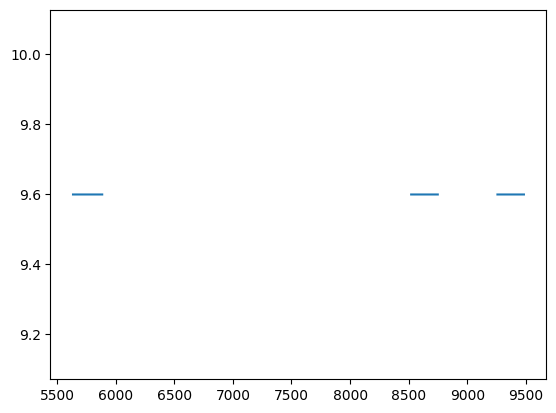

In [54]:
import matplotlib.pyplot as plt
ev_data = ev_load[veh_id_list[1]]
plt.figure()
plt.plot(ev_data)
plt.show()

In [1]:
from actions import DataOperator 
import matplotlib.pyplot as plt
from actions import get_stats
from datetime import datetime
import pickle
import os

# paths = {}
# paths['transformer_data'] = 'C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/tf_mapping_MEAD2104.csv'
# paths['charge_event_data'] = 'C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/Xcel_Charge_Events_Home_GPS.csv'
# paths['base_load_data'] = 'C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/MEAD2104_tfs_kva.csv'
# paths['uncontrolled_ev_load_data'] = 'C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/EV_profiles_weekly_Greedy.csv' # This only for September

# dop = DataOperator(paths, 'MEAD2104', [9])

paths = {}
paths['mappings'] = 'C:\\Users\\eucer\\OneDrive - NREL\\Desktop\\NREL Work\\Projects\\EVI-Dist_v1\\EVI-Dist\\data\\mappings\\mappings.pkl'
paths['premise_report'] = 'C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/premise_data/10_feeders_premise_report.csv'
paths['ev_adoption'] = 'C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/adoptions/2030/high.csv'
paths['baseload_profiles'] = 'C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/temp/baseload_upsampled.csv'
paths['ev_profiles'] = 'C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/temp/ev_profiles.csv' # This only for September

dop = DataOperator(paths, 'MEAD2104', [9])

In [23]:
table = dop.get_table()
table.head(30)

starting_index = int()
for index, row in table.iterrows():
    
    if str(row['Transformer ID']) in dop.base_load.columns:
        print(f"{row['Transformer ID']} exists, index = {index}")
        starting_index = index
        break
    else:
        print(f"{row['Transformer ID']} does not exists, index = {index}")
        


236941482 does not exists, index = 0
236922941 exists, index = 1


In [2]:
ev_list = dop.get_veh_ids_for_xf(236952409)
base_load_by_xf = dop.get_base_load_by_xf_id(236952409)
ev_load_by_id = dop.get_ev_load_by_veh_id(ev_list[2])
agg_ev_load_by_xf = dop.get_agg_ev_load_by_xf_id(236952409)
feeder_load = dop.get_feeder_load()
agg_ev_load_by_feeder = dop.get_agg_ev_load_by_feeder()
time = dop.get_time()
table = dop.get_table()

print(type(time))
print(type(ev_list))
print(type(base_load_by_xf))
print(type(feeder_load))
print(type(ev_load_by_id))
print(type(agg_ev_load_by_xf))

# plt.figure()
# plt.plot(base_load_by_xf)
# plt.show()

# plt.figure()
# plt.plot(ev_load_by_id)
# plt.show()

# plt.figure()
# plt.plot(agg_ev_load_by_xf)
# plt.show()

# plt.figure()
# plt.plot(feeder_load)
# plt.show()

# plt.figure()
# plt.plot(agg_ev_load_by_feeder)
# plt.show()



<class 'list'>
<class 'list'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


c:\Users\eucer\OneDrive - NREL\Desktop\NREL Work\Projects\EVI-Dist_v1\EVI-Dist\dashboard\actions.py:113: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  f = self.base_load.iloc[:,1:].sum(axis=1)


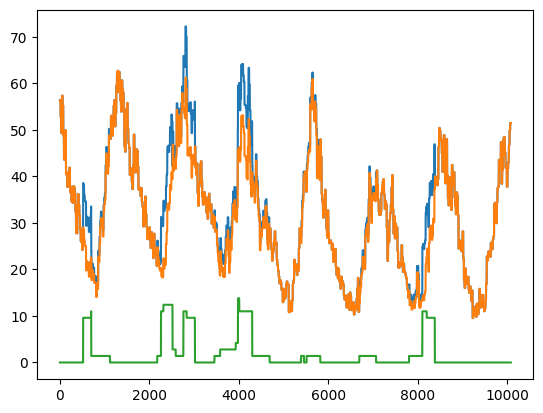

In [7]:
import sys
sys.path.append('../modules')

from data_structures import Signal

base_load_signal = Signal(time, base_load_by_xf, 'Baseload', 60)
ev_load_signal = Signal(time, agg_ev_load_by_xf, 'EV+Baseload', 60)

total_load_signal = base_load_signal + ev_load_signal

plt.figure()
plt.plot(total_load_signal.y)
plt.plot(base_load_signal.y)
plt.plot(ev_load_signal.y)
plt.show()


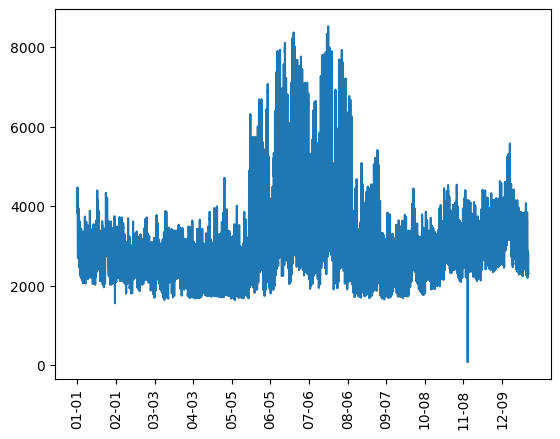

In [3]:
ts_base_load_by_xf = TimeSeries(base_load_by_xf, 'xf_load', 15*60)
ts_agg_ev_load_by_xf = TimeSeries(agg_ev_load_by_xf, 'agg_ev_load_by_xf', 60, datetime(2024, 9, 1, 0, 0, 0)) # This datetime should be automated

ts_feeder_load = TimeSeries(feeder_load, 'feeder_load', 15*60)
ts_agg_ev_load_by_feeder = TimeSeries(agg_ev_load_by_feeder, 'agg_ev_load', 60, datetime(2024, 9, 1, 0, 0, 0)) # This datetime should be automated


plt.figure()
plt.plot(ts_feeder_load.ts['t']/60/60/24, ts_feeder_load.ts['value'])
plt.xticks(ts_feeder_load.ts['t'][::3000]/60/60/24, [date_obj.strftime('%m-%d') for date_obj in ts_feeder_load.ts['ft'][::3000]], rotation=90)
plt.show()


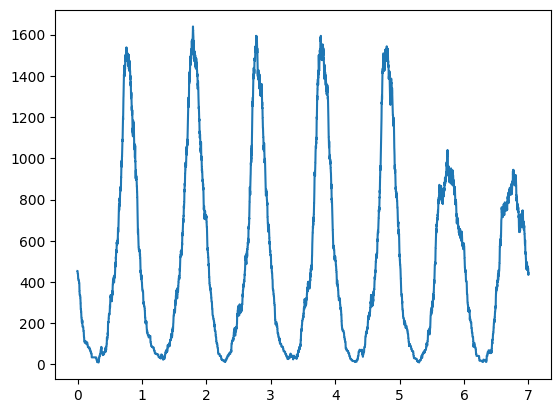

In [5]:

plt.figure()
plt.plot(ts_agg_ev_load_by_feeder.ts['t']/60/60/24, ts_agg_ev_load_by_feeder.ts['value'])
plt.show()

0 10079
0 10079
[0.0000e+00 6.0000e+01 1.2000e+02 ... 6.0456e+05 6.0462e+05 6.0468e+05]
[datetime.datetime(2024, 9, 1, 0, 0), datetime.datetime(2024, 9, 1, 0, 1), datetime.datetime(2024, 9, 1, 0, 2), datetime.datetime(2024, 9, 1, 0, 3), datetime.datetime(2024, 9, 1, 0, 4), datetime.datetime(2024, 9, 1, 0, 5), datetime.datetime(2024, 9, 1, 0, 6), datetime.datetime(2024, 9, 1, 0, 7), datetime.datetime(2024, 9, 1, 0, 8), datetime.datetime(2024, 9, 1, 0, 9), datetime.datetime(2024, 9, 1, 0, 10), datetime.datetime(2024, 9, 1, 0, 11), datetime.datetime(2024, 9, 1, 0, 12), datetime.datetime(2024, 9, 1, 0, 13), datetime.datetime(2024, 9, 1, 0, 14), datetime.datetime(2024, 9, 1, 0, 15), datetime.datetime(2024, 9, 1, 0, 16), datetime.datetime(2024, 9, 1, 0, 17), datetime.datetime(2024, 9, 1, 0, 18), datetime.datetime(2024, 9, 1, 0, 19), datetime.datetime(2024, 9, 1, 0, 20), datetime.datetime(2024, 9, 1, 0, 21), datetime.datetime(2024, 9, 1, 0, 22), datetime.datetime(2024, 9, 1, 0, 23), datetime.

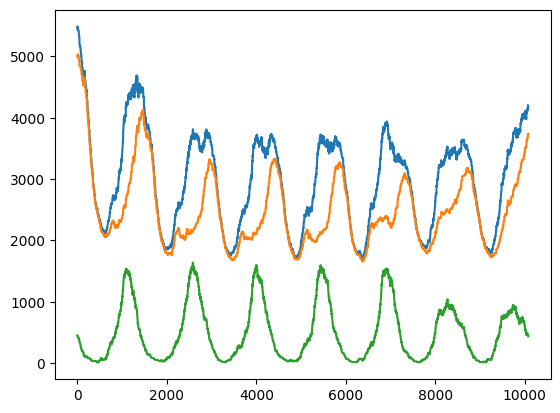

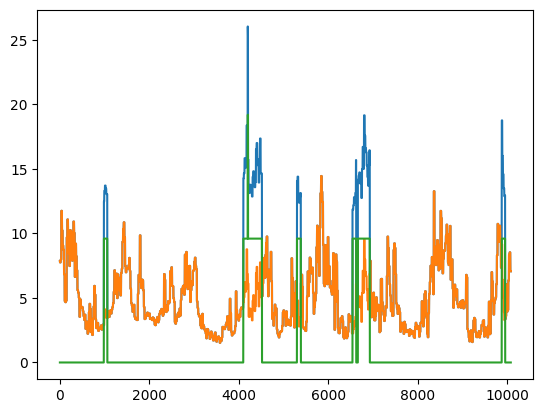

####################################################################

                    Max loading : 14.453 kVA

                    Min loading : 1.5262 kVA

                    Average loading : 1.5262 kVA

                    Duration above 5 kVA : 65.48333333333333 h

                    Likelihood of overloading above 5 kVA : 38.98204186923306 %

                    ####################################################################


{'max': 14.453,
 'min': 1.5262,
 'avg': 4.894688292489334,
 'dat': 65.48333333333333,
 'lot': 38.98204186923306}

In [4]:
ts_combined_load_feeder = ts_feeder_load + ts_agg_ev_load_by_feeder

ts_combined_load_by_xf = ts_base_load_by_xf + ts_agg_ev_load_by_xf

t = ts_combined_load_by_xf['t']
ft = ts_combined_load_by_xf['ft']

print(t)
print(ft)
print([date.strftime('%Y-%m-%d') for date in ft[::1440]])

plt.figure()
plt.plot(ts_combined_load_feeder['total'])
plt.plot(ts_combined_load_feeder['value_1'])
plt.plot(ts_combined_load_feeder['value_2'])
plt.show()

plt.figure()
plt.plot(ts_combined_load_by_xf['total'])
plt.plot(ts_combined_load_by_xf['value_1'])
plt.plot(ts_combined_load_by_xf['value_2'])
plt.show()

# plt.figure()
# plt.plot(total_power['t']/60/60/24, total_power['total'])
# plt.plot(total_power['t']/60/60/24, total_power['value_1'])
# plt.plot(total_power['t']/60/60/24, total_power['value_2'])
# plt.xticks(total_power['t'][::50]/60/60/24, [date_obj.strftime('%m-%d - %H:%M') for date_obj in total_power['ft'][::50]], rotation=90)
# plt.show()

get_stats(ts_combined_load_by_xf['value_1'], 5)


In [2]:
fff = dop.get_table()
fff.head()

,Feeder,Transformer ID,OID_,OPCO,AMI percent,Bank Size
0,MEAD2104,66372578,2484171,PSCO,0.888889,100
1,MEAD2104,76772451,2490372,PSCO,1.000000,50
2,MEAD2104,76772492,2490373,PSCO,1.000000,50
3,MEAD2104,76772523,2490374,PSCO,1.000000,50
4,MEAD2104,76772554,2490375,PSCO,1.000000,50


In [1]:
from actions import gen_xf_mappings
import pickle
file_names = {}
file_names['premise_report_data'] = 'C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/premise_data/10_feeders_premise_report.csv'
file_names['charge_event_data'] = 'C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/back_up/data collection/Xcel_Charge_Events_Home_GPS.csv'

mappings = gen_xf_mappings(file_names)

#print(mappings['xf_mappings']['MEAD2104'])

for value in mappings['xf_mappings']['MEAD2104']:
    print('XF:', value)
    print('Vehicles:', mappings['xf_mappings']['MEAD2104'][value]['vehicles'])
    print('Premises:', mappings['xf_mappings']['MEAD2104'][value]['premises'])
    print('----------------------------------------')

10.0
20.0
30.0
40.0
50.0
60.0
70.0
80.0
90.0
100.0
XF: 236941482
Vehicles: []
Premises: [300951535 301102423 301253355 301404343 301555547 301857077 301857078]
----------------------------------------
XF: 236922941
Vehicles: ['Veh_129176' 'Veh_129220' 'Veh_128973' 'Veh_128947']
Premises: [301253012 300951188 304701570 301403996 300800174 301705912 304530066
 301404021 300800181]
----------------------------------------
XF: 236941091
Vehicles: ['Veh_119779' 'Veh_119591' 'Veh_119625' 'Veh_119700']
Premises: [301857081 301364559 301515777 300911596 301515733 301062710 301817310
 301062766 301253358 301364256 301062549 301817070 301515524 301364163
 300760377 301515655]
----------------------------------------
XF: 236932943
Vehicles: ['Veh_128941']
Premises: [301208613 300755571 301057736 301359252 301962951 301962602 301811954
 300906332 300755411]
----------------------------------------
XF: 236951843
Vehicles: []
Premises: [301555829 301253677 304293603 300800858 300951902 301404729 301

In [2]:
from actions import get_feeder_names
import pickle

with open('C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/dashboard/mappings2.pkl', "rb") as f:
    variables = pickle.load(f)

get_feeder_names(mappings=variables)

BTER1341B
BTER1342B
BTER1347B
BTER1349B
BTER1356B
MEAD2059
MEAD2104
MURP1210
MURP1312
SMDT1384


In [10]:
import json
import os

file_path = "c:\\Users\\eucer\\OneDrive - NREL\\Desktop\\NREL Work\\Projects\\EVI-Dist_v1\\EVI-Dist\\data\\inputs\\adoption_scenarios.json"

with open(file_path, "rb") as json_file:
    loaded_data = json.load(json_file)

print([f for f in loaded_data])


['2030 (Low)', '2030 (Medium)', '2030 (High)', '2040 (Low)', '2040 (Medium)', '2040 (High)']


In [32]:
import pandas as pd
from datetime import datetime, date, time, timedelta
import numpy as np

file_path = "c:\\Users\\eucer\\OneDrive - NREL\\Desktop\\NREL Work\\Projects\\EVI-Dist_v1\\EVI-Dist\\data\\ev_charging_data\\EV_profiles_weekly_Greedy.csv"

df = pd.read_csv(file_path)

data_len = len(df)
res = 60 #sec
print(data_len)
t = np.linspace(0, (data_len-1) * res, data_len)
start_time = datetime(year=2023, month=9, day=1, hour=0, minute=0, second=0)
formatted_t = [start_time + timedelta(seconds=res*i) for i in range(data_len)]

print(formatted_t)

new_df = df.iloc[:,4:]
new_df.insert(0,'time', formatted_t)
new_df.head()

new_df.to_csv("c:\\Users\\eucer\\OneDrive - NREL\\Desktop\\NREL Work\\Projects\\EVI-Dist_v1\\EVI-Dist\\data\\ev_charging_data\\ev_profiles.csv")



10080
[datetime.datetime(2023, 9, 1, 0, 0), datetime.datetime(2023, 9, 1, 0, 1), datetime.datetime(2023, 9, 1, 0, 2), datetime.datetime(2023, 9, 1, 0, 3), datetime.datetime(2023, 9, 1, 0, 4), datetime.datetime(2023, 9, 1, 0, 5), datetime.datetime(2023, 9, 1, 0, 6), datetime.datetime(2023, 9, 1, 0, 7), datetime.datetime(2023, 9, 1, 0, 8), datetime.datetime(2023, 9, 1, 0, 9), datetime.datetime(2023, 9, 1, 0, 10), datetime.datetime(2023, 9, 1, 0, 11), datetime.datetime(2023, 9, 1, 0, 12), datetime.datetime(2023, 9, 1, 0, 13), datetime.datetime(2023, 9, 1, 0, 14), datetime.datetime(2023, 9, 1, 0, 15), datetime.datetime(2023, 9, 1, 0, 16), datetime.datetime(2023, 9, 1, 0, 17), datetime.datetime(2023, 9, 1, 0, 18), datetime.datetime(2023, 9, 1, 0, 19), datetime.datetime(2023, 9, 1, 0, 20), datetime.datetime(2023, 9, 1, 0, 21), datetime.datetime(2023, 9, 1, 0, 22), datetime.datetime(2023, 9, 1, 0, 23), datetime.datetime(2023, 9, 1, 0, 24), datetime.datetime(2023, 9, 1, 0, 25), datetime.dateti

In [55]:
import pandas as pd
from datetime import datetime, date, time, timedelta
import numpy as np

file_path = "c:\\Users\\eucer\\OneDrive - NREL\\Desktop\\NREL Work\\Projects\\EVI-Dist_v1\\EVI-Dist\\data\\ami_data\\MEAD2104_tfs_kva.csv"
ami_data = pd.read_csv(file_path)

start_date = pd.to_datetime(new_df.iloc[0]['time'])
end_date = pd.to_datetime(new_df.iloc[-1]['time'])

# print(start_date)
# print(end_date)
# print(type(pd.to_datetime(ami_data['time'][0])))

ami_data['time'] = pd.to_datetime(ami_data['time'])

# start_index = ami_data[ami_data['time'] == start_date]
# end_index = ami_data[ami_data['time'] == end_date]

start_time = min(ami_data['time'], key=lambda x: abs(x - start_date))
end_time = min(ami_data['time'], key=lambda x: abs(x - end_date))

print(start_time)
start_index = ami_data.index[ami_data['time'] == start_time]
print(start_index)

print(end_time)
end_index = ami_data.index[ami_data['time'] == end_time]
print(end_index)

baseload_profile = ami_data.iloc[start_index[0]:end_index[0]]

baseload_profile.head()


2023-09-01 00:00:00
Int64Index([20448], dtype='int64')
2023-09-08 00:00:00
Int64Index([21120], dtype='int64')


,time,66372578,76772451,76772492,76772523,76772554,153834634,153834668,153834702,153836463,...,237660463,237660478,237660493,237660508,237660523,237685745,237685760,421069056,481712906,736998870
20448,2023-09-01 00:00:00,16.5295,16.1129,16.9579,14.2444,11.4805,10.7612,34.1271,17.3821,18.8538,...,25.6280,41.2659,29.8606,40.2818,24.3634,45.6095,33.5364,0.6320,19.9886,0.580
20449,2023-09-01 00:15:00,12.4391,16.4556,17.0639,15.3601,10.1499,10.3027,32.1215,15.8962,19.2599,...,19.1186,40.5076,31.0675,34.7038,22.1963,39.4437,32.7564,0.1200,24.0501,0.584
20450,2023-09-01 00:30:00,15.1821,13.8274,15.9098,14.3367,10.7077,10.3677,27.3038,14.4827,17.0614,...,25.5847,45.4294,31.8013,38.8709,22.2710,37.5068,32.2257,1.2040,25.2460,0.584
20451,2023-09-01 00:45:00,11.7442,10.6450,14.0549,15.6602,13.0402,9.5817,28.5579,13.7965,16.6457,...,23.1401,37.9295,37.1624,36.9129,22.0168,39.5864,28.4994,0.9561,22.7084,0.588
20452,2023-09-01 01:00:00,10.8450,13.5816,14.0758,17.3920,12.1705,8.8294,22.8735,12.3984,11.3341,...,22.9057,40.5221,32.9873,35.9303,15.2914,38.0356,22.4901,0.8201,21.3339,0.588


In [108]:
t = baseload_profile.iloc[0]['time']

frames = []

for i, row in baseload_profile.iterrows():
    t = row['time']
    new_time = [t + timedelta(minutes=j) for j in range(15)]
    new_rows = pd.concat([pd.DataFrame(row).transpose()] * 15, ignore_index=True)
    new_rows['time'] = new_time
    frames.append(new_rows)

# Concatenate all DataFrames in the list
upsampled_baseload_profile = pd.concat(frames, ignore_index=True)

upsampled_baseload_profile.head()
upsampled_baseload_profile.to_csv("c:\\Users\\eucer\\OneDrive - NREL\\Desktop\\NREL Work\\Projects\\EVI-Dist_v1\\EVI-Dist\\data\\temp\\baseload_upsampled.csv")



In [120]:
import sys
sys.path.append('../modules')

from data_structures import Signal

s1 = Signal([1,2,3,4], [10,11,12,13], 'Baseload', 60)
s2 = Signal([1,2,3,4], [6,7,9,30], 'EV+Baseload', 60)

s3 = s1 + s2

print(s3.y)


[16, 18, 21, 43]


In [2]:
import sys
import os
current_working_directory = os.getcwd()
parent_directory = os.path.dirname(current_working_directory)
print(parent_directory)
sys.path.append(parent_directory)
from modules.simulation import SimLite

input_files = dict()
configs = dict()

input_files['premise_report'] = parent_directory + "\\data\premise data\\10_feeders_premise_report.csv"
input_files['ev_adoption'] = parent_directory + "\\data\\adoptions\\2030\\high.csv"

configs['feeder'] = "MEAD2104"
configs['controller'] = ['Uncontrolled', 'TOU_ASAP', 'TOU_ALAP', 'TOU_random']
configs['adoption'] = '2030 High'
configs['load_profile'] = 'AMI Only'
configs['ami_data_file'] = parent_directory + "\\ami_data\\MEAD2104_tfs_kva.csv"
configs['month_of_interset'] = 9

sim = SimLite(input_files, configs)
sim.run()

c:\Users\eucer\OneDrive - NREL\Desktop\NREL Work\Projects\EVI-Dist_v1\EVI-Dist


<>:12: SyntaxWarning: invalid escape sequence '\p'
<>:12: SyntaxWarning: invalid escape sequence '\p'
C:\Users\eucer\AppData\Local\Temp\1\ipykernel_66016\389037082.py:12: SyntaxWarning: invalid escape sequence '\p'
  input_files['premise_report'] = parent_directory + "\\data\premise data\\10_feeders_premise_report.csv"


ModuleNotFoundError: No module named 'pandas'

In [1]:
import pandas as pd
df_ami = pd.read_csv('C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/ami_data/MEAD2104_tfs_kva.csv')
df_ami['time'] = pd.to_datetime(df_ami['time'], format='%m/%d/%Y %H:%M')

month = 9
df_september = df_ami[df_ami['time'].dt.month == month]

year = df_september['time'].dt.year.iloc[0]

# Find the first September date
first_september = pd.Timestamp(f'{year}-09-01')

# Calculate the first Monday of September
first_monday = first_september + pd.DateOffset(days=(7 - first_september.weekday()) % 7)

# Calculate the first Sunday after the first Monday
first_sunday = first_monday + pd.DateOffset(days=6)

# Filter the DataFrame to include only dates between the first Monday and the first Sunday
filtered_df = df_september[(df_september['time'] >= first_monday) & (df_september['time'] <= first_sunday)]

# Print the first Monday and Sunday
print("First Monday of September:", first_monday)
print("First Sunday after the first Monday:", first_sunday)

# Print the filtered DataFrame
print("\nFiltered DataFrame:")
filtered_df.tail()




First Monday of September: 2023-09-04 00:00:00
First Sunday after the first Monday: 2023-09-10 00:00:00

Filtered DataFrame:


,time,66372578,76772451,76772492,76772523,76772554,153834634,153834668,153834702,153836463,...,237660463,237660478,237660493,237660508,237660523,237685745,237685760,421069056,481712906,736998870
21308,2023-09-09 23:00:00,11.6331,8.8850,14.3419,11.1174,9.0249,16.1492,28.4238,10.5441,14.6472,...,20.1656,30.4776,16.1557,23.8184,16.1503,37.1505,22.9231,0.2585,9.3840,0.588
21309,2023-09-09 23:15:00,13.3699,11.4121,14.4417,10.2872,9.0876,13.6269,30.1296,11.1975,12.2043,...,13.2760,23.6075,13.8331,22.6054,15.8687,36.1919,23.6778,0.2999,14.7368,0.584
21310,2023-09-09 23:30:00,11.7416,10.6650,13.1156,11.6381,10.1120,16.5333,28.1862,10.1007,8.5021,...,17.7089,27.1479,18.9461,23.2790,14.8142,44.7361,21.7902,0.1842,11.7873,0.588
21311,2023-09-09 23:45:00,11.6137,11.2376,12.1502,10.9537,12.2183,14.5935,23.1129,9.2490,9.0898,...,16.4549,27.2717,17.7539,20.1990,12.3686,38.5159,19.7862,0.1241,10.2407,0.588
21312,2023-09-10 00:00:00,11.1812,8.7799,15.8249,11.6402,9.6318,13.8400,21.5379,11.0336,14.0983,...,18.5284,34.0076,14.5098,19.1481,14.2948,37.2299,21.5957,0.1760,7.3157,0.588


In [8]:
import pandas as pd
from datetime import datetime, timedelta

def generate_upsampled_baseload(df, month):
    # Convert the 'time' column to datetime format
    print("Generating baseload profiles...")
    file_path_to_save = os.getcwd() + "\\data\\temp\\baseload_profiles.csv"

    df['time'] = pd.to_datetime(df['time'])

    # Extract the year from the first row of the DataFrame
    year = df['time'].dt.year.iloc[0]

    # Get the first day of the given month and year
    start_date = datetime(year=year, month=month, day=1)

    # Find the first Monday of the month
    first_monday = start_date + timedelta(days=(7 - start_date.weekday()) % 7)

    # Find the first Sunday of the month
    first_sunday = first_monday + timedelta(days=6)

    # Filter rows between the first Monday and the first Sunday
    filtered_df = df[(df['time'] >= first_monday) & (df['time'] < first_sunday + timedelta(days=1))]

    # Generate 1-minute resolution timestamps within the selected range
    new_times = pd.date_range(start=first_monday, end=first_sunday + timedelta(days=1), freq='1min')

    # Create a DataFrame with the new timestamps
    new_times_df = pd.DataFrame({'time': new_times})

    # Merge the new timestamps DataFrame with the filtered DataFrame
    upsampled_df = new_times_df.merge(filtered_df, how='left', on='time')

    # Forward fill missing values
    upsampled_df = upsampled_df.ffill()

    # Create the 'date' column with the format '1/31/2023 0:00'
    upsampled_df['date'] = upsampled_df['time'].dt.strftime('%m/%d/%Y %H:%M')

    # Extract time as timedelta for 'time' column
    upsampled_df['time'] = upsampled_df['time'].dt.time

    # Calculate the day column starting from 1
    upsampled_df['day'] = (upsampled_df.index // (24 * 60) + 1).astype(int)

    # Reorder columns
    upsampled_df = upsampled_df[['day', 'time', 'date'] + [col for col in df.columns if col != 'time']]

    # Save
    return upsampled_df
    print("Completed!")

# Example usage
# df is your pandas DataFrame with the first column as 'time'
# month is the month number (1 for January, 2 for February, etc.)
# upsampled_df = generate_upsampled_dataframe(df, month)

import pandas as pd
df_ami = pd.read_csv('C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/ami_data/MEAD2104_tfs_kva.csv')
new_df = generate_upsampled_dataframe(df_ami, 1)
new_df.to_csv('C:/Users/eucer/OneDrive - NREL/Desktop/NREL Work/Projects/EVI-Dist_v1/EVI-Dist/data/temp/new_ami2.csv')